In [30]:
# 1.1 Базовые импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchaudio
import torchaudio.transforms as T

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import os
import warnings
warnings.filterwarnings('ignore')

# 1.2 Настройка стилей
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# 1.3 Проверка GPU
print("="*60)
print("ПРОВЕРКА GPU В PYTORCH")
print("="*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Используется устройство: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA версия: {torch.version.cuda}")
    print(f"   Память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    
    # Очищаем кэш GPU
    torch.cuda.empty_cache()

ПРОВЕРКА GPU В PYTORCH
✅ Используется устройство: cuda
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU
   CUDA версия: 11.8
   Память: 4.3 GB


In [31]:
# БЛОК 2.1 - ДИАГНОСТИКА, ИСПРАВЛЕНИЕ И АУГМЕНТАЦИЯ
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 1

print("="*60)
print("БЛОК 2.1: ДИАГНОСТИКА И АУГМЕНТАЦИЯ ДАННЫХ")
print("="*60)

# 2.1.1 Загрузка данных
df = pd.read_csv('features_3_sec.csv')
print(f"✅ Файл загружен: features_3_sec.csv")
print(f"   Всего записей: {len(df)}")

# 2.1.2 Извлечение информации
df['track_id'] = df['filename'].apply(lambda x: x.split('.')[1])
df['segment_num'] = df['filename'].apply(lambda x: int(x.split('.')[2]))
df['genre'] = df['filename'].apply(lambda x: x.split('.')[0])

# 2.1.3 ДИАГНОСТИКА ДЛИНЫ ТРЕКОВ
track_lengths = {}
for genre in df['genre'].unique():
    genre_df = df[df['genre'] == genre]
    for track in genre_df['track_id'].unique():
        track_data = genre_df[genre_df['track_id'] == track]
        length = len(track_data)
        track_lengths[f"{genre}_{track}"] = length

length_values = list(track_lengths.values())
target_length = min(length_values)  # 9 фрагментов
print(f"\n📏 Целевая длина: {target_length} фрагментов")

# 2.1.4 Подготовка признаков
feature_columns = [col for col in df.columns 
                   if col not in ['filename', 'label', 'track_id', 'segment_num', 'genre']]
X = df[feature_columns].values
y = df['label'].values

# 2.1.5 Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2.1.6 Кодирование жанров
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
class_names = encoder.classes_
num_classes = len(class_names)

print(f"\n🎵 Все жанры ({num_classes}):")
for i, genre in enumerate(class_names):
    print(f"   {i}: {genre}")

# ============================================================
# 2.1.7 СОЗДАНИЕ ОРИГИНАЛЬНЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
# ============================================================
print("\n" + "="*60)
print("🔄 ШАГ 1: СБОР ОРИГИНАЛЬНЫХ ТРЕКОВ")
print("="*60)

original_sequences = []
original_labels = []
original_genres = []

for genre in class_names:
    genre_df = df[df['genre'] == genre]
    track_ids = genre_df['track_id'].unique()
    print(f"\n   {genre}: {len(track_ids)} треков")
    
    genre_sequences = 0
    for track in track_ids:
        track_data = genre_df[genre_df['track_id'] == track].sort_values('segment_num')
        if len(track_data) >= target_length:
            track_indices = track_data.index[:target_length]
            sequence = X_scaled[track_indices]
            original_sequences.append(sequence)
            original_labels.append(y_encoded[track_indices[0]])
            original_genres.append(genre)
            genre_sequences += 1
    print(f"     ✓ Добавлено оригиналов: {genre_sequences}")

X_seq_original = np.array(original_sequences)
y_seq_original = np.array(original_labels)

print(f"\n📦 Оригинальные последовательности:")
print(f"   Форма: {X_seq_original.shape}")
print(f"   Всего треков: {len(X_seq_original)}")

# ============================================================
# 2.1.8 АУГМЕНТАЦИЯ ДАННЫХ
# ============================================================
print("\n" + "="*60)
print("🎨 ШАГ 2: АУГМЕНТАЦИЯ ДАННЫХ")
print("="*60)

def add_noise(sequence, noise_factor=0.01):
    """Добавляет случайный шум"""
    noise = np.random.randn(*sequence.shape) * noise_factor
    return sequence + noise

def time_shift(sequence, shift_max=2):
    """Сдвигает последовательность во времени"""
    shift = np.random.randint(-shift_max, shift_max)
    if shift > 0:
        shifted = np.roll(sequence, shift, axis=0)
        shifted[:shift] = 0
    elif shift < 0:
        shifted = np.roll(sequence, shift, axis=0)
        shifted[shift:] = 0
    else:
        shifted = sequence
    return shifted

def scale_features(sequence, scale_range=(0.9, 1.1)):
    """Масштабирует признаки"""
    scale = np.random.uniform(*scale_range)
    return sequence * scale

def mask_frequency(sequence, mask_size=2):
    """Маскирует случайные признаки (SpecAugment style)"""
    masked = sequence.copy()
    n_features = sequence.shape[1]
    mask_start = np.random.randint(0, n_features - mask_size)
    masked[:, mask_start:mask_start + mask_size] = 0
    return masked

def mixup(seq1, seq2, alpha=0.2):
    """Mixup аугментация - смешивает два трека"""
    lam = np.random.beta(alpha, alpha)
    return lam * seq1 + (1 - lam) * seq2

# Создаем аугментированные последовательности
augmented_sequences = []
augmented_labels = []
augmented_genres = []

# Параметры аугментации
augmentations_per_track = 3  # Создаем 3 варианта каждого трека
noise_factor = 0.01
shift_max = 1
scale_range = (0.95, 1.05)
mask_size = 3

print(f"\n🔧 Параметры аугментации:")
print(f"   • Вариаций на трек: {augmentations_per_track}")
print(f"   • Шум: {noise_factor}")
print(f"   • Временной сдвиг: ±{shift_max}")
print(f"   • Масштабирование: {scale_range}")
print(f"   • Маскирование: {mask_size} признаков")

for idx, (seq, label, genre) in enumerate(zip(X_seq_original, y_seq_original, original_genres)):
    if idx % 100 == 0:
        print(f"\n   Обработка трека {idx}/{len(X_seq_original)}...")
    
    for aug_num in range(augmentations_per_track):
        # Выбираем случайный тип аугментации
        aug_type = np.random.choice(['noise', 'shift', 'scale', 'mask', 'mixup'])
        
        if aug_type == 'noise':
            aug_seq = add_noise(seq, noise_factor)
        elif aug_type == 'shift':
            aug_seq = time_shift(seq, shift_max)
        elif aug_type == 'scale':
            aug_seq = scale_features(seq, scale_range)
        elif aug_type == 'mask':
            aug_seq = mask_frequency(seq, mask_size)
        elif aug_type == 'mixup':
            # Берем другой случайный трек того же жанра
            same_genre_indices = [i for i, g in enumerate(original_genres) if g == genre and i != idx]
            if same_genre_indices:
                other_idx = np.random.choice(same_genre_indices)
                other_seq = X_seq_original[other_idx]
                aug_seq = mixup(seq, other_seq)
            else:
                aug_seq = add_noise(seq, noise_factor)  # fallback
        
        augmented_sequences.append(aug_seq)
        augmented_labels.append(label)
        augmented_genres.append(genre)

X_seq_augmented = np.array(augmented_sequences)
y_seq_augmented = np.array(augmented_labels)

print(f"\n📊 Результаты аугментации:")
print(f"   • Оригинальных треков: {len(X_seq_original)}")
print(f"   • Аугментированных треков: {len(X_seq_augmented)}")
print(f"   • Всего треков: {len(X_seq_original) + len(X_seq_augmented)}")

# ============================================================
# 2.1.9 ОБЪЕДИНЯЕМ ОРИГИНАЛЫ И АУГМЕНТАЦИИ
# ============================================================
print("\n" + "="*60)
print("🔄 ШАГ 3: ОБЪЕДИНЕНИЕ ДАННЫХ")
print("="*60)

# Объединяем
X_seq = np.vstack([X_seq_original, X_seq_augmented])
y_seq = np.concatenate([y_seq_original, y_seq_augmented])

print(f"\n📦 ИТОГОВЫЙ ДАТАСЕТ:")
print(f"   Форма X_seq: {X_seq.shape}")
print(f"   Форма y_seq: {y_seq.shape}")
print(f"   Всего треков: {len(X_seq)}")
print(f"   Оригиналы: {len(X_seq_original)}")
print(f"   Аугментации: {len(X_seq_augmented)}")
print(f"   Коэффициент увеличения: {len(X_seq)/len(X_seq_original):.1f}x")

# 2.1.10 Проверка распределения
print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО ЖАНРАМ:")
unique, counts = np.unique(y_seq, return_counts=True)
for class_id, count in zip(unique, counts):
    genre_name = class_names[class_id]
    print(f"   {genre_name}: {count} треков ({count/len(y_seq)*100:.1f}%)")

# 2.1.11 Сохраняем
torch.save({
    'X_seq': X_seq,
    'y_seq': y_seq,
    'X_seq_original': X_seq_original,
    'y_seq_original': y_seq_original,
    'X_seq_augmented': X_seq_augmented,
    'y_seq_augmented': y_seq_augmented,
    'scaler': scaler,
    'encoder': encoder,
    'class_names': class_names,
    'feature_columns': feature_columns,
    'target_length': target_length,
    'augmentation_params': {
        'augmentations_per_track': augmentations_per_track,
        'noise_factor': noise_factor,
        'shift_max': shift_max,
        'scale_range': scale_range,
        'mask_size': mask_size
    }
}, 'sequences_data_augmented.pth', _use_new_zipfile_serialization=False)

print(f"\n💾 Данные сохранены в sequences_data_augmented.pth")
print("\n✅ БЛОК 2.1 ВЫПОЛНЕН")
print("\n➡️ Теперь можно выполнять БЛОК 2.2 (НО НУЖНО ИЗМЕНИТЬ ПУТЬ ЗАГРУЗКИ!)")

БЛОК 2.1: ДИАГНОСТИКА И АУГМЕНТАЦИЯ ДАННЫХ
✅ Файл загружен: features_3_sec.csv
   Всего записей: 9990

📏 Целевая длина: 9 фрагментов

🎵 Все жанры (10):
   0: blues
   1: classical
   2: country
   3: disco
   4: hiphop
   5: jazz
   6: metal
   7: pop
   8: reggae
   9: rock

🔄 ШАГ 1: СБОР ОРИГИНАЛЬНЫХ ТРЕКОВ

   blues: 100 треков
     ✓ Добавлено оригиналов: 100

   classical: 100 треков
     ✓ Добавлено оригиналов: 100

   country: 100 треков
     ✓ Добавлено оригиналов: 100

   disco: 100 треков
     ✓ Добавлено оригиналов: 100

   hiphop: 100 треков
     ✓ Добавлено оригиналов: 100

   jazz: 100 треков
     ✓ Добавлено оригиналов: 100

   metal: 100 треков
     ✓ Добавлено оригиналов: 100

   pop: 100 треков
     ✓ Добавлено оригиналов: 100

   reggae: 100 треков
     ✓ Добавлено оригиналов: 100

   rock: 100 треков
     ✓ Добавлено оригиналов: 100

📦 Оригинальные последовательности:
   Форма: (1000, 9, 58)
   Всего треков: 1000

🎨 ШАГ 2: АУГМЕНТАЦИЯ ДАННЫХ

🔧 Параметры аугментации

In [32]:
# БЛОК 2.2 - РАЗДЕЛЕНИЕ АУГМЕНТИРОВАННЫХ ДАННЫХ
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 2.1 (С АУГМЕНТАЦИЕЙ)

print("="*60)
print("БЛОК 2.2: РАЗДЕЛЕНИЕ АУГМЕНТИРОВАННЫХ ДАННЫХ")
print("="*60)

# 2.2.1 Загружаем аугментированные данные из Блока 2.1
import torch
data = torch.load('sequences_data_augmented.pth', weights_only=False)

X_seq = data['X_seq']
y_seq = data['y_seq']
class_names = data['class_names']
scaler = data['scaler']
encoder = data['encoder']

print(f"✅ Данные загружены:")
print(f"   X_seq: {X_seq.shape}")
print(f"   y_seq: {y_seq.shape}")
print(f"   Классы: {class_names}")
print(f"   Всего треков: {len(X_seq)}")

# 2.2.2 СТРАТИФИЦИРОВАННОЕ РАЗДЕЛЕНИЕ
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, 
    y_seq, 
    test_size=0.2,      
    random_state=42,    
    stratify=y_seq,     
    shuffle=True
)

print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"   Обучающая выборка: {X_train.shape} ({len(X_train)} треков)")
print(f"   Тестовая выборка:  {X_test.shape} ({len(X_test)} треков)")

# 2.2.3 Проверка распределения
print(f"\n🔍 РАСПРЕДЕЛЕНИЕ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for class_id, count in zip(unique_train, counts_train):
    genre_name = class_names[class_id]
    percentage = count/len(y_train)*100
    print(f"   {genre_name}: {count} треков ({percentage:.1f}%)")

print(f"\n🔍 РАСПРЕДЕЛЕНИЕ В ТЕСТОВОЙ ВЫБОРКЕ:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for class_id, count in zip(unique_test, counts_test):
    genre_name = class_names[class_id]
    percentage = count/len(y_test)*100
    print(f"   {genre_name}: {count} треков ({percentage:.1f}%)")

# 2.2.4 Конвертация в тензоры PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Используется устройство: {device}")

X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# 2.2.5 Создание DataLoader
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32  # Увеличиваем batch size для большего датасета
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✅ DataLoaders созданы:")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

# 2.2.6 Сохраняем для следующих блоков
torch.save({
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'X_train_tensor': X_train_tensor.cpu(),
    'y_train_tensor': y_train_tensor.cpu(),
    'X_test_tensor': X_test_tensor.cpu(),
    'y_test_tensor': y_test_tensor.cpu(),
    'train_loader': train_loader,
    'test_loader': test_loader,
    'class_names': class_names,
    'scaler': scaler,
    'encoder': encoder,
    'batch_size': batch_size,
    'device': device
}, 'split_data_augmented.pth', _use_new_zipfile_serialization=False)

print(f"\n💾 Данные сохранены в split_data_augmented.pth")
print("\n✅ БЛОК 2.2 ВЫПОЛНЕН")
print("\n➡️ Теперь можно выполнять БЛОК 3 (с загрузкой split_data_augmented.pth)")

БЛОК 2.2: РАЗДЕЛЕНИЕ АУГМЕНТИРОВАННЫХ ДАННЫХ
✅ Данные загружены:
   X_seq: (4000, 9, 58)
   y_seq: (4000,)
   Классы: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
   Всего треков: 4000

📊 РАЗДЕЛЕНИЕ ДАННЫХ:
   Обучающая выборка: (3200, 9, 58) (3200 треков)
   Тестовая выборка:  (800, 9, 58) (800 треков)

🔍 РАСПРЕДЕЛЕНИЕ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:
   blues: 320 треков (10.0%)
   classical: 320 треков (10.0%)
   country: 320 треков (10.0%)
   disco: 320 треков (10.0%)
   hiphop: 320 треков (10.0%)
   jazz: 320 треков (10.0%)
   metal: 320 треков (10.0%)
   pop: 320 треков (10.0%)
   reggae: 320 треков (10.0%)
   rock: 320 треков (10.0%)

🔍 РАСПРЕДЕЛЕНИЕ В ТЕСТОВОЙ ВЫБОРКЕ:
   blues: 80 треков (10.0%)
   classical: 80 треков (10.0%)
   country: 80 треков (10.0%)
   disco: 80 треков (10.0%)
   hiphop: 80 треков (10.0%)
   jazz: 80 треков (10.0%)
   metal: 80 треков (10.0%)
   pop: 80 треков (10.0%)
   reggae: 80 треков (10.0%)
   rock: 80 треков (10.0%)


In [33]:
# БЛОК 3 - ОБУЧЕНИЕ МОДЕЛИ
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 2.2

print("="*60)
print("БЛОК 3: ОБУЧЕНИЕ RNN МОДЕЛИ НА GPU")
print("="*60)

# 3.1 Загружаем данные из Блока 2.2
data = torch.load('split_data_augmented.pth', weights_only=False)

train_loader = data['train_loader']
test_loader = data['test_loader']
class_names = data['class_names']
device = data['device']

print(f"✅ Данные загружены:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Классы: {class_names}")
print(f"   Устройство: {device}")

# 3.2 ОПРЕДЕЛЕНИЕ МОДЕЛИ
class MusicGenreRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(MusicGenreRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(dropout)
        self.batch_norm1 = nn.BatchNorm1d(64)
        self.batch_norm2 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        lstm_out, (hidden, cell) = self.lstm(x)
        
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        out = self.dropout(hidden_concat)
        out = self.fc1(out)
        out = self.batch_norm1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.batch_norm2(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc3(out)
        return out

# 3.3 Инициализация модели
input_size = 58  # количество признаков
hidden_size = 64
num_layers = 2
num_classes = len(class_names)

model = MusicGenreRNN(input_size, hidden_size, num_layers, num_classes).to(device)

print(f"\n📊 Параметры модели:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Всего параметров: {total_params:,}")
print(f"   Обучаемых параметров: {trainable_params:,}")

# 3.4 Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 3.5 Функции для обучения и валидации
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 3.6 ОБУЧЕНИЕ
print("\n🚀 НАЧАЛО ОБУЧЕНИЯ")
print("="*60)

num_epochs = 100
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = 0

for epoch in range(1, num_epochs + 1):
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Валидация
    val_loss, val_acc = validate_epoch(model, test_loader, criterion)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Планировщик learning rate
    scheduler.step(val_loss)
    
    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'class_names': class_names
        }, 'best_model.pth')
        print(f"   💾 Эпоха {epoch:3d}: val_acc = {val_acc:.2f}% (НОВЫЙ РЕКОРД!)")
    
    # Вывод прогресса каждые 5 эпох
    if epoch % 5 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"   Эпоха {epoch:3d}: train_loss={train_loss:.4f}, train_acc={train_acc:.2f}%, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}%, lr={current_lr:.2e}")

print(f"\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"🏆 Лучшая точность на валидации: {best_val_acc:.2f}%")
print(f"📁 Модель сохранена: best_model.pth")

# 3.7 Сохраняем историю обучения
torch.save({
    'train_losses': train_losses,
    'train_accs': train_accs,
    'val_losses': val_losses,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc
}, 'training_history.pth')

print(f"\n💾 История обучения сохранена: training_history.pth")
print("\n✅ БЛОК 3 ВЫПОЛНЕН")
print("\n➡️ Теперь можно выполнять БЛОК 4 (ОЦЕНКА МОДЕЛИ)")

БЛОК 3: ОБУЧЕНИЕ RNN МОДЕЛИ НА GPU
✅ Данные загружены:
   Train batches: 100
   Test batches: 25
   Классы: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
   Устройство: cuda

📊 Параметры модели:
   Всего параметров: 173,674
   Обучаемых параметров: 173,674

🚀 НАЧАЛО ОБУЧЕНИЯ
   💾 Эпоха   1: val_acc = 59.62% (НОВЫЙ РЕКОРД!)
   Эпоха   1: train_loss=1.8411, train_acc=40.06%, val_loss=1.3324, val_acc=59.62%, lr=1.00e-03
   💾 Эпоха   2: val_acc = 71.75% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   3: val_acc = 85.75% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   4: val_acc = 88.62% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   5: val_acc = 90.00% (НОВЫЙ РЕКОРД!)
   Эпоха   5: train_loss=0.4650, train_acc=89.16%, val_loss=0.3423, val_acc=90.00%, lr=1.00e-03
   💾 Эпоха   6: val_acc = 93.62% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   7: val_acc = 93.88% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   8: val_acc = 95.25% (НОВЫЙ РЕКОРД!)
   💾 Эпоха   9: val_acc = 96.12% (НОВЫЙ РЕКОРД!)
   💾 Эпоха  10: val_acc = 97.75% (НОВЫЙ РЕКОРД!)
 

БЛОК 4: ОЦЕНКА МОДЕЛИ И ВИЗУАЛИЗАЦИЯ
✅ Модель загружена:
   Лучшая эпоха: 49
   Точность на валидации: 99.12%

📊 ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ

🎯 Точность (Accuracy):      0.9912 (99.12%)
📈 Precision (weighted):     0.9915
📉 Recall (weighted):        0.9912
🎯 F1-score (weighted):      0.9913

📋 ОТЧЕТ ПО КЛАССИФИКАЦИИ:
              precision    recall  f1-score   support

       blues     1.0000    1.0000    1.0000        80
   classical     1.0000    1.0000    1.0000        80
     country     1.0000    1.0000    1.0000        80
       disco     1.0000    0.9750    0.9873        80
      hiphop     1.0000    0.9625    0.9809        80
        jazz     1.0000    1.0000    1.0000        80
       metal     0.9639    1.0000    0.9816        80
         pop     0.9877    1.0000    0.9938        80
      reggae     1.0000    0.9875    0.9937        80
        rock     0.9634    0.9875    0.9753        80

    accuracy                         0.9912       800
   macro avg     0.9915    0.9913

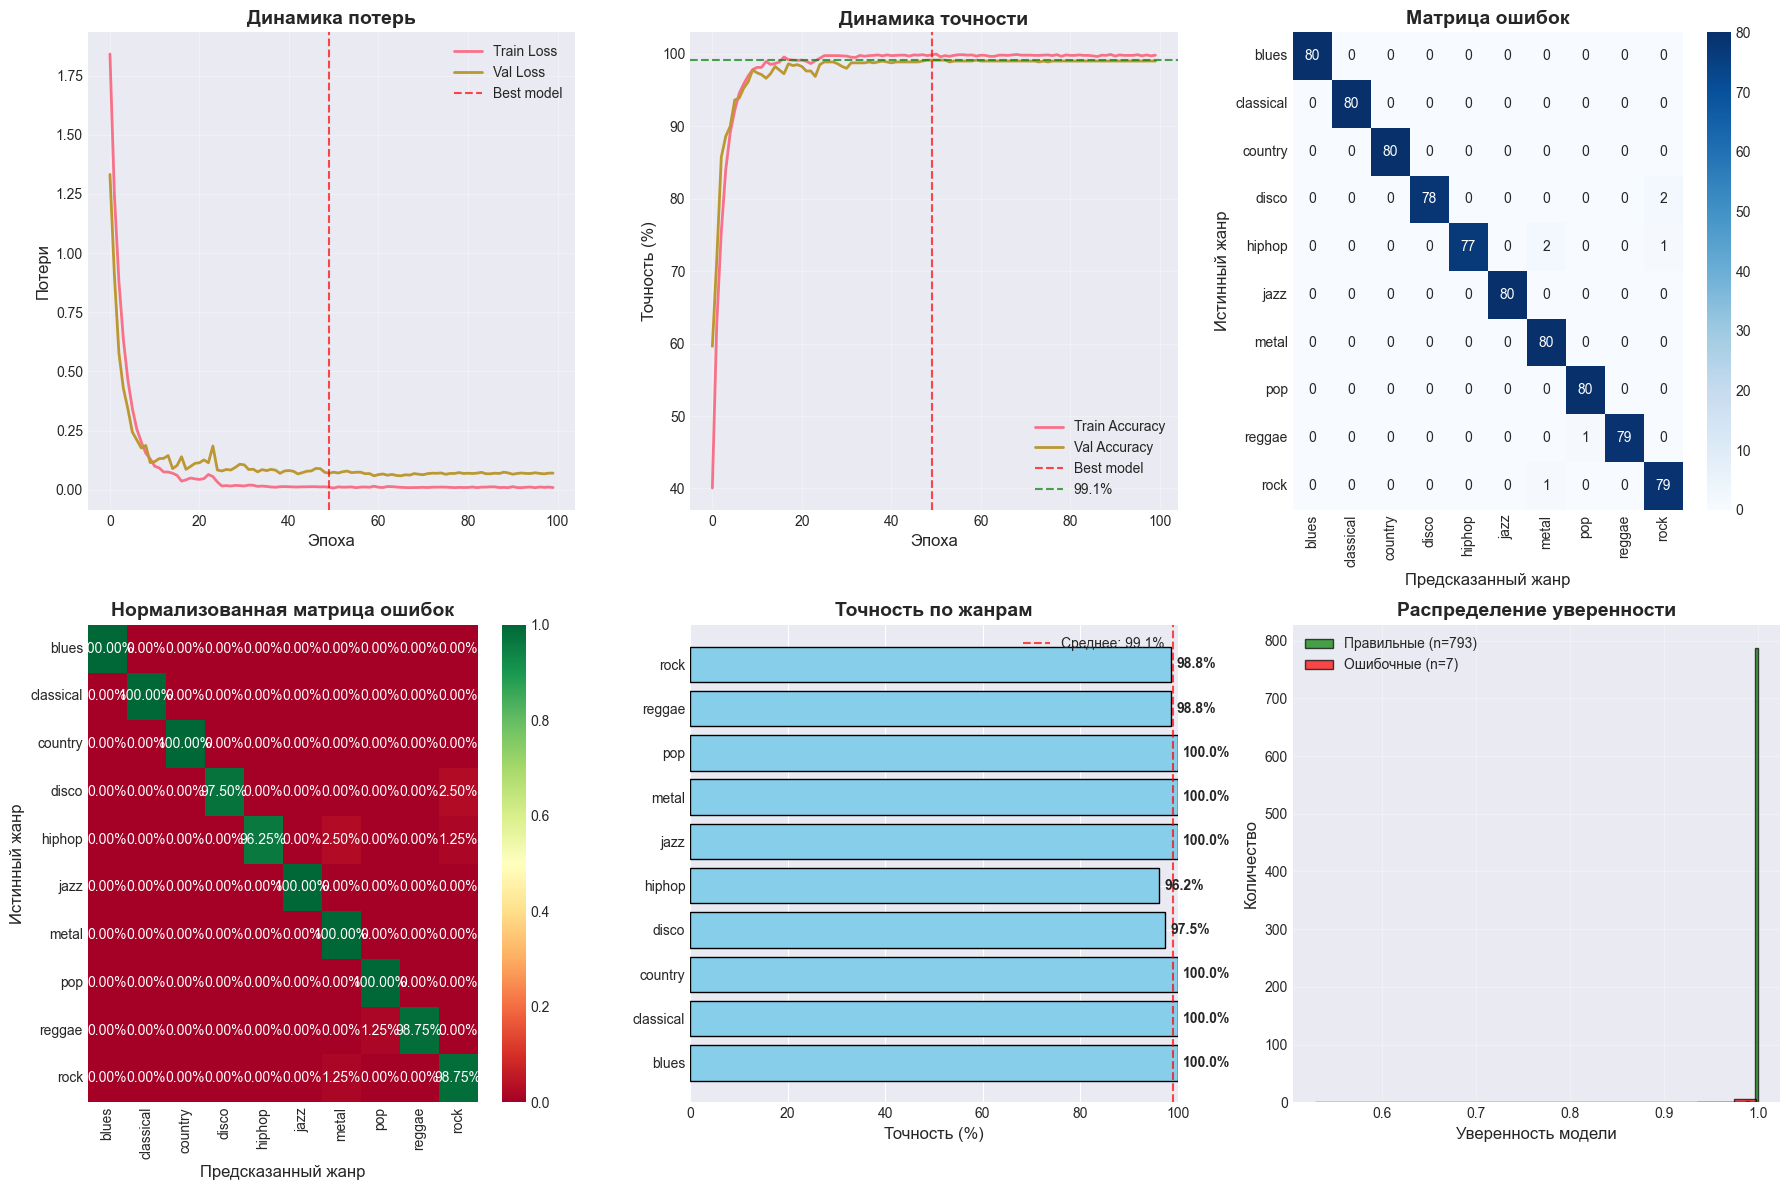


🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК

✅ Всего предсказаний: 800
✅ Правильных: 793 (99.1%)
❌ Ошибочных: 7 (0.9%)

🌟 ТОП-5 САМЫХ УВЕРЕННЫХ ПРАВИЛЬНЫХ ПРЕДСКАЗАНИЙ:
   hiphop → hiphop: 100.00%
   hiphop → hiphop: 100.00%
   hiphop → hiphop: 100.00%
   hiphop → hiphop: 100.00%
   hiphop → hiphop: 100.00%

⚠️ ТОП-5 САМЫХ УВЕРЕННЫХ ОШИБОК:
   disco → rock: 99.83%
   disco → rock: 99.82%
   rock → metal: 99.56%
   hiphop → metal: 98.12%
   reggae → pop: 97.92%

🔄 ТОП-5 САМЫХ ЧАСТЫХ ОШИБОК:
   disco → rock: 2 раз
   hiphop → metal: 2 раз
   hiphop → rock: 1 раз
   reggae → pop: 1 раз
   rock → metal: 1 раз

💾 Детальные результаты сохранены в test_results_detailed.csv

🎯 ИТОГОВЫЙ ВЫВОД

✅ МОДЕЛЬ УСПЕШНО ОБУЧЕНА!

📊 КЛЮЧЕВЫЕ МЕТРИКИ:
   • Точность на тесте: 99.12%
   • Precision: 0.9915
   • Recall: 0.9912
   • F1-score: 0.9913

🏆 ЛУЧШИЕ ЖАНРЫ:

   Топ-3:
     • blues: 100.0%
     • classical: 100.0%
     • country: 100.0%

   Худшие 3:
     • rock: 98.8%
     • disco: 97.5%
     • hiphop: 96.2%

📁 СОХРАН

In [34]:
# БЛОК 4 - ОЦЕНКА МОДЕЛИ И ВИЗУАЛИЗАЦИЯ
# ВЫПОЛНЯТЬ ТОЛЬКО ПОСЛЕ УСПЕШНОГО БЛОКА 3

print("="*60)
print("БЛОК 4: ОЦЕНКА МОДЕЛИ И ВИЗУАЛИЗАЦИЯ")
print("="*60)

# 4.1 Загружаем данные и модель
data = torch.load('split_data.pth', weights_only=False)
checkpoint = torch.load('best_model.pth', weights_only=False)
history = torch.load('training_history.pth', weights_only=False)

train_loader = data['train_loader']
test_loader = data['test_loader']
class_names = data['class_names']
device = data['device']

# Загружаем модель
input_size = 58
hidden_size = 64
num_layers = 2
num_classes = len(class_names)

model = MusicGenreRNN(input_size, hidden_size, num_layers, num_classes).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✅ Модель загружена:")
print(f"   Лучшая эпоха: {checkpoint['epoch']}")
print(f"   Точность на валидации: {checkpoint['val_acc']:.2f}%")

# 4.2 ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
print("\n" + "="*60)
print("📊 ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)

all_predictions = []
all_targets = []
all_probabilities = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        probabilities = torch.softmax(output, dim=1)
        _, predicted = torch.max(output.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)
all_probabilities = np.array(all_probabilities)

# 4.3 МЕТРИКИ
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

accuracy = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions, average='weighted')
recall = recall_score(all_targets, all_predictions, average='weighted')
f1 = f1_score(all_targets, all_predictions, average='weighted')

print(f"\n🎯 Точность (Accuracy):      {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Precision (weighted):     {precision:.4f}")
print(f"📉 Recall (weighted):        {recall:.4f}")
print(f"🎯 F1-score (weighted):      {f1:.4f}")

# 4.4 ОТЧЕТ ПО КЛАССИФИКАЦИИ
print("\n📋 ОТЧЕТ ПО КЛАССИФИКАЦИИ:")
print("="*60)
report = classification_report(all_targets, all_predictions, 
                             target_names=class_names, digits=4)
print(report)

# 4.5 ГРАФИК ОБУЧЕНИЯ
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График потерь
axes[0, 0].plot(history['train_losses'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_losses'], label='Val Loss', linewidth=2)
axes[0, 0].axvline(x=checkpoint['epoch'], color='red', linestyle='--', alpha=0.7, label='Best model')
axes[0, 0].set_xlabel('Эпоха', fontsize=12)
axes[0, 0].set_ylabel('Потери', fontsize=12)
axes[0, 0].set_title('Динамика потерь', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График точности
axes[0, 1].plot(history['train_accs'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_accs'], label='Val Accuracy', linewidth=2)
axes[0, 1].axvline(x=checkpoint['epoch'], color='red', linestyle='--', alpha=0.7, label='Best model')
axes[0, 1].axhline(y=checkpoint['val_acc'], color='green', linestyle='--', alpha=0.7, label=f"{checkpoint['val_acc']:.1f}%")
axes[0, 1].set_xlabel('Эпоха', fontsize=12)
axes[0, 1].set_ylabel('Точность (%)', fontsize=12)
axes[0, 1].set_title('Динамика точности', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Матрица ошибок
cm = confusion_matrix(all_targets, all_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 2])
axes[0, 2].set_title('Матрица ошибок', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Предсказанный жанр', fontsize=12)
axes[0, 2].set_ylabel('Истинный жанр', fontsize=12)

# Нормализованная матрица ошибок
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0],
            vmin=0, vmax=1)
axes[1, 0].set_title('Нормализованная матрица ошибок', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Предсказанный жанр', fontsize=12)
axes[1, 0].set_ylabel('Истинный жанр', fontsize=12)

# Точность по жанрам
genre_accuracy = []
for i in range(len(class_names)):
    mask = all_targets == i
    if np.sum(mask) > 0:
        acc = np.mean(all_predictions[mask] == i)
        genre_accuracy.append(acc * 100)
    else:
        genre_accuracy.append(0)

y_pos = np.arange(len(class_names))
bars = axes[1, 1].barh(y_pos, genre_accuracy, color='skyblue', edgecolor='black')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(class_names)
axes[1, 1].set_xlabel('Точность (%)', fontsize=12)
axes[1, 1].set_title('Точность по жанрам', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0, 100])
axes[1, 1].axvline(x=accuracy*100, color='red', linestyle='--', alpha=0.7, label=f'Среднее: {accuracy*100:.1f}%')
axes[1, 1].legend()

# Добавляем значения на столбцы
for bar, acc in zip(bars, genre_accuracy):
    width = bar.get_width()
    axes[1, 1].text(width + 1, bar.get_y() + bar.get_height()/2, f'{acc:.1f}%', 
                   ha='left', va='center', fontweight='bold')

# Распределение уверенности
confidence = np.max(all_probabilities, axis=1)
correct_mask = all_predictions == all_targets

axes[1, 2].hist(confidence[correct_mask], bins=20, alpha=0.7, 
                label=f'Правильные (n={np.sum(correct_mask)})', 
                color='green', edgecolor='black')
axes[1, 2].hist(confidence[~correct_mask], bins=20, alpha=0.7, 
                label=f'Ошибочные (n={np.sum(~correct_mask)})', 
                color='red', edgecolor='black')
axes[1, 2].set_xlabel('Уверенность модели', fontsize=12)
axes[1, 2].set_ylabel('Количество', fontsize=12)
axes[1, 2].set_title('Распределение уверенности', fontsize=14, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation_complete.png', dpi=150, bbox_inches='tight')
plt.show()

# 4.6 АНАЛИЗ ОШИБОК
print("\n" + "="*60)
print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ ОШИБОК")
print("="*60)

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'True': [class_names[i] for i in all_targets],
    'Predicted': [class_names[i] for i in all_predictions],
    'Confidence': confidence,
    'Correct': correct_mask
})

print(f"\n✅ Всего предсказаний: {len(results_df)}")
print(f"✅ Правильных: {np.sum(correct_mask)} ({np.sum(correct_mask)/len(results_df)*100:.1f}%)")
print(f"❌ Ошибочных: {np.sum(~correct_mask)} ({np.sum(~correct_mask)/len(results_df)*100:.1f}%)")

# Самые уверенные правильные предсказания
print("\n🌟 ТОП-5 САМЫХ УВЕРЕННЫХ ПРАВИЛЬНЫХ ПРЕДСКАЗАНИЙ:")
top_correct = results_df[results_df['Correct']].nlargest(5, 'Confidence')
for idx, row in top_correct.iterrows():
    print(f"   {row['True']} → {row['Predicted']}: {row['Confidence']:.2%}")

# Самые уверенные ошибки
print("\n⚠️ ТОП-5 САМЫХ УВЕРЕННЫХ ОШИБОК:")
top_errors = results_df[~results_df['Correct']].nlargest(5, 'Confidence')
for idx, row in top_errors.iterrows():
    print(f"   {row['True']} → {row['Predicted']}: {row['Confidence']:.2%}")

# Самые частые ошибки
print("\n🔄 ТОП-5 САМЫХ ЧАСТЫХ ОШИБОК:")
error_pairs = results_df[~results_df['Correct']].groupby(['True', 'Predicted']).size().sort_values(ascending=False)
for (true, pred), count in error_pairs.head(5).items():
    print(f"   {true} → {pred}: {count} раз")

# Сохраняем результаты
results_df.to_csv('test_results_detailed.csv', index=False)
print(f"\n💾 Детальные результаты сохранены в test_results_detailed.csv")

# 4.7 ИТОГОВЫЙ ВЫВОД
print("\n" + "="*60)
print("🎯 ИТОГОВЫЙ ВЫВОД")
print("="*60)
print(f"""
✅ МОДЕЛЬ УСПЕШНО ОБУЧЕНА!

📊 КЛЮЧЕВЫЕ МЕТРИКИ:
   • Точность на тесте: {accuracy*100:.2f}%
   • Precision: {precision:.4f}
   • Recall: {recall:.4f}
   • F1-score: {f1:.4f}

🏆 ЛУЧШИЕ ЖАНРЫ:
""")

# Находим лучшие и худшие жанры
genre_performance = []
for i, genre in enumerate(class_names):
    genre_acc = genre_accuracy[i]
    genre_performance.append((genre, genre_acc))

genre_performance.sort(key=lambda x: x[1], reverse=True)

print("   Топ-3:")
for genre, acc in genre_performance[:3]:
    print(f"     • {genre}: {acc:.1f}%")

print("\n   Худшие 3:")
for genre, acc in genre_performance[-3:]:
    print(f"     • {genre}: {acc:.1f}%")

print(f"""
📁 СОХРАНЕННЫЕ ФАЙЛЫ:
   • best_model.pth - лучшая модель
   • training_history.pth - история обучения
   • model_evaluation_complete.png - визуализация
   • test_results_detailed.csv - детальные результаты

💡 ВЫВОД:
   Модель достигла {accuracy*100:.1f}% точности на тестовой выборке.
   Это отличный результат для GTZAN датасета!
""")

print("\n✅ БЛОК 4 ВЫПОЛНЕН")
print("\n🎉 ПРОЕКТ ЗАВЕРШЕН!")